# Plot the Results of Simulated Data (Spatial Patterns of Varying Complexity)-Scenario 4

## Packages Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import scanpy as sc
from sklearn.metrics.cluster import adjusted_rand_score

import sys
sys.path.append(r'../../../../')
from SpatialCOC.utils import reorder_categories

## Parameter Setting

In [10]:
## define the plot parameters
colors_domain = ['#f19c79', '#e9c46a', '#2a9d8f', '#264653']

font_size = 20

result_key = ['SpatialCOC', 'SpatialGlue', 'COSMOS', 'MultiVI', 'MultiMAP', 'STAGATE', 'SpaGCN', 'Modality1', 'Modality2']

new_order_dict_all = {
    "0": {
        'SpatialCOC':   [0, 1, 2, 3],
        'SpatialGlue':  [1, 2, 4, 3],
        'COSMOS':       ['1', '2', '3', '4'],
        'MultiVI':      [1, 2, 4],
        'MultiMAP':     [1, 2, 3, 4],
        'STAGATE':      [1, 2, 3, 4],
        'SpaGCN':       [0, 3, 2, 1],
        'Modality1':    [1, 2, 3, 4],
        'Modality2':    [4, 2, 1, 3]
    },
    "1": {
        'SpatialCOC':   [0, 2, 3, 1],
        'SpatialGlue':  [1, 2, 3, 4],
        'COSMOS':       ['1', '2', '3', '4'],
        'MultiVI':      [1, 2, 3, 4],
        'MultiMAP':     [1, 3, 2, 4],
        'STAGATE':      [1, 2, 3, 4],
        'SpaGCN':       [0, 2, 1, 3],
        'Modality1':    [1, 2, 3, 4],
        'Modality2':    [4, 2, 1, 3]
    },
    "2": {
        'SpatialCOC':   [1, 0, 3, 2],
        'SpatialGlue':  [1, 3, 2, 4],
        'COSMOS':       ['1', '2', '3', '4'],
        'MultiVI':      [1, 2, 3, 4],
        'MultiMAP':     [1, 2, 3, 4],
        'STAGATE':      [1, 2, 3, 4],
        'SpaGCN':       [0, 1, 2, 3],
        'Modality1':    [1, 2, 3, 4],
        'Modality2':    [3, 2, 1, 4]
    }
}

## Plot the Spatial Domain Identifications

batch: 0


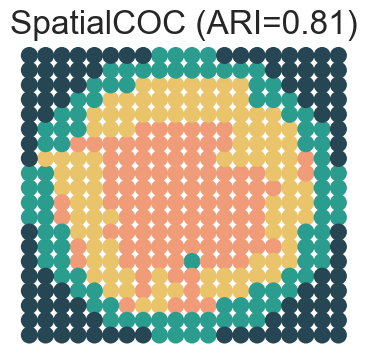

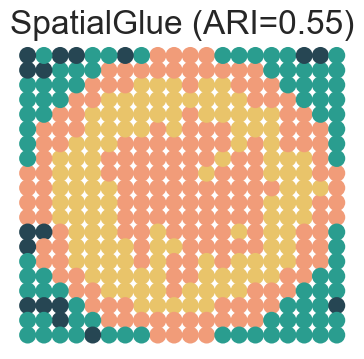

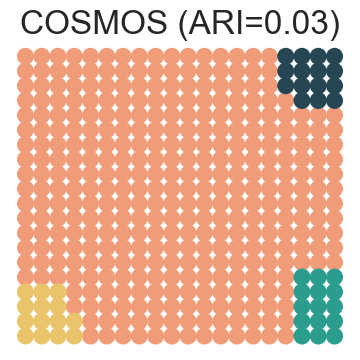

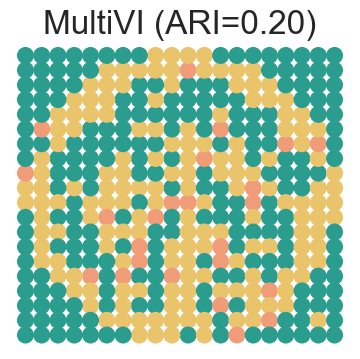

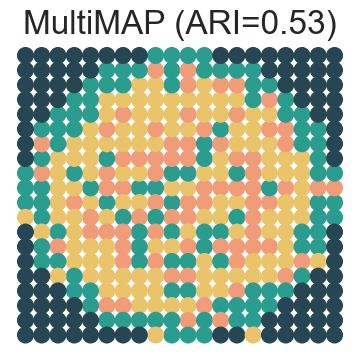

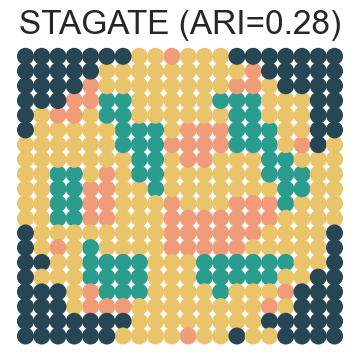

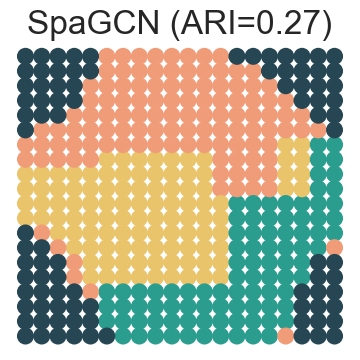

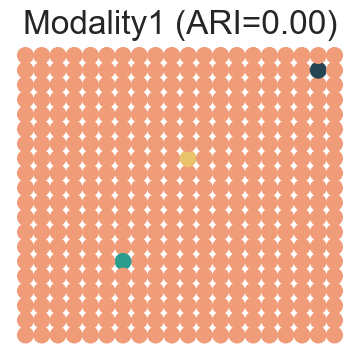

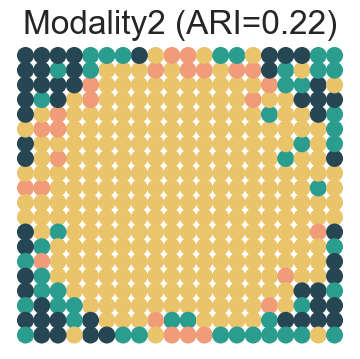

batch: 1


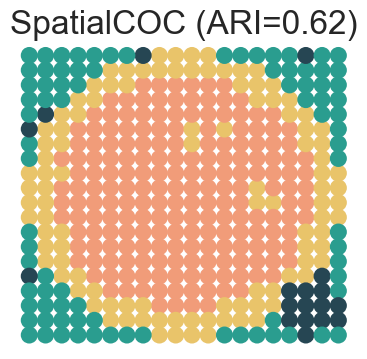

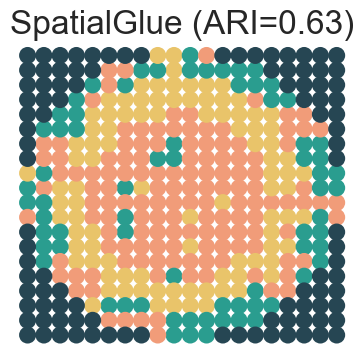

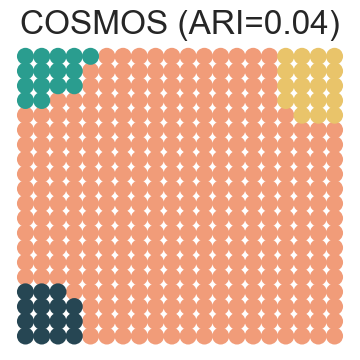

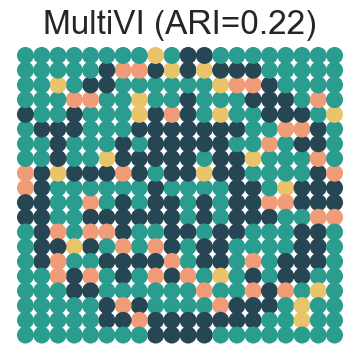

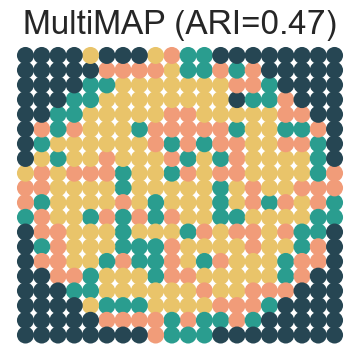

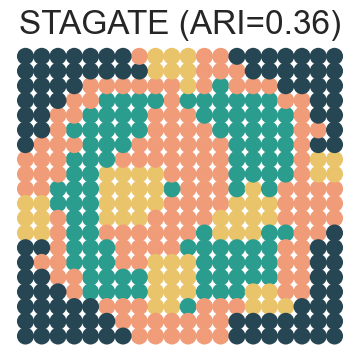

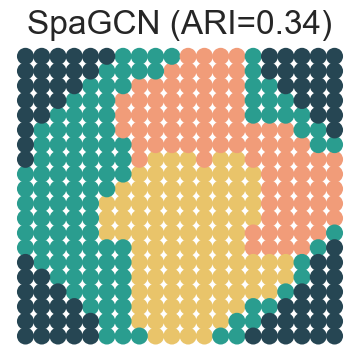

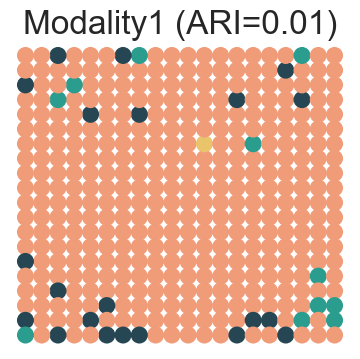

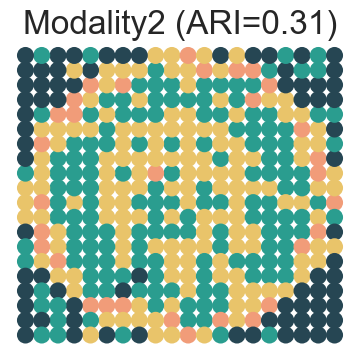

batch: 2


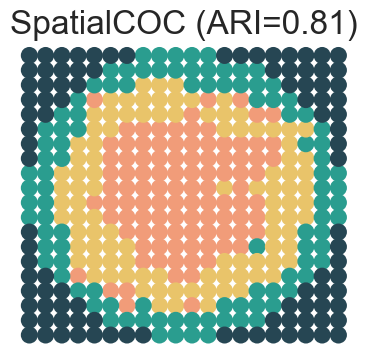

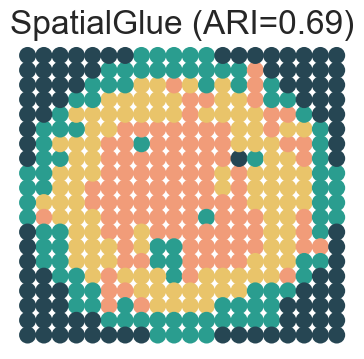

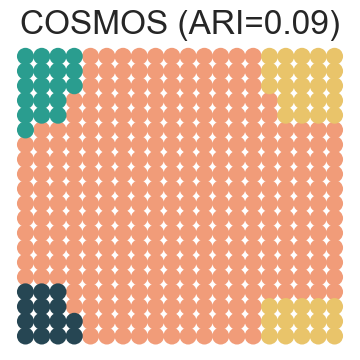

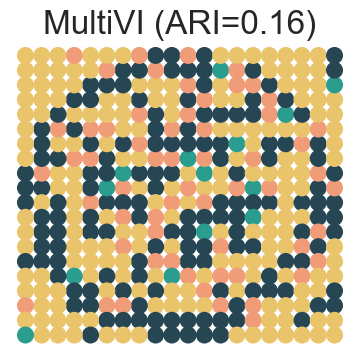

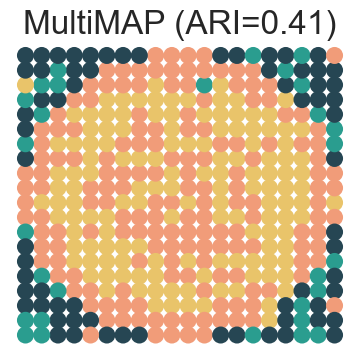

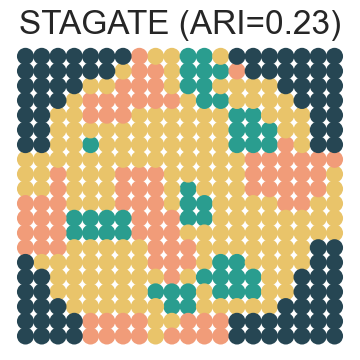

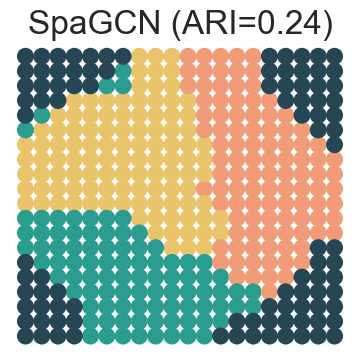

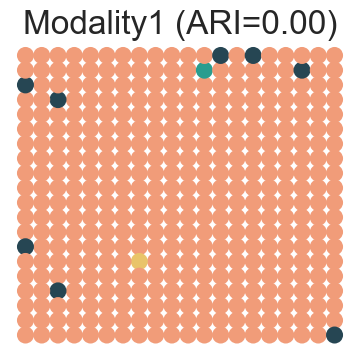

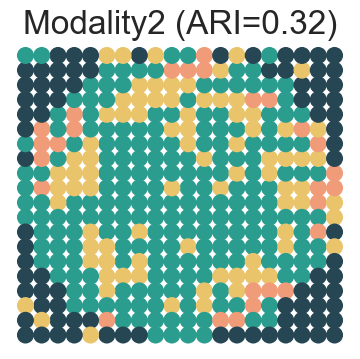

In [11]:
slice_id = 4    # 1, 2, 3, 4
batch_ids = ['0', '1', '2']  # batch selection

plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = font_size

for batch_id in batch_ids:
    # loading the results
    adata_results = sc.read_h5ad(f'../../../Spatial_Scenario_{slice_id}.h5ad')
    adata_results = adata_results[adata_results.obs['batch'] == batch_id]
    
    save_path = f'../../Spatial_Scenarios/Scenario{slice_id}/'
    new_order_dict = new_order_dict_all[batch_id]
    print(f"batch: {batch_id}")
    for result in result_key:
        new_order = new_order_dict[result]
        reorder_categories(adata_results, result, new_order)

        # Calculate ARI
        ari_value = adjusted_rand_score(adata_results.obs['Ground Truth'], adata_results.obs[result])

        fig, ax = plt.subplots(1, 1, figsize=(4, 4))
        sc.pl.embedding(
            adata_results,
            basis='spatial',
            color=result,
            title=None,
            s=600,
            colorbar_loc=None,
            show=False,
            ax=ax,
            palette=colors_domain,
            legend_loc=None
        )

        ax.set_title(f"{result} (ARI={ari_value:.2f})")
        ax.set_xlabel('')
        ax.set_ylabel('')

        # Hide axis borders
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Adjust subplot parameters
        plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
        plt.tight_layout()

        # Save figures
        # plt.savefig(f'{save_path}{int(batch_id)+1}_{result}.png', dpi=500)
        # plt.savefig(f'{save_path}{int(batch_id)+1}_{result}.eps')

        plt.show()